# **BioPred Phase 1 EDA**

In this portion of the project, we will look to:

1. Take our queried phase 1 data and analyze it with dabl and sweetviz.

2. Use the results and any observed insights and dig into them further to learn more about our features.

3. Look into relationships between the features and see what potential features can be derived before we get to our Feature Engineering ntbk next.

#### First let's read back in our parquet file that we created in our previous data_ingest notebook where we first imported and queried the data for this project. [View the main_ingest notebook here](/home/azureuser/cloudfiles/code/Users/kalpha1865/BioPred/Notebooks/data_ingest_acq/main_ingest.ipynb).  We will also read in our libraries needed as well so that we have the tools needed for this notebook.

In [6]:
# List libraries needed for this notebook.
import pandas as pd
import numpy as np
import dabl
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

# Importing warnings to filter out warnings we receive
import warnings
warnings.filterwarnings("ignore", message = "Could not infer format")

In [2]:
# Quickly setting plot style to ggplot
plt.style.use('ggplot')

In [3]:
# Establish file path
file_path = "/home/azureuser/cloudfiles/code/Users/kalpha1865/BioPred/Data/df_files/df_phase_1.parquet"
eda_df = pd.read_parquet(file_path)

#### Now let's just do some quick overview on our data before we continue to get an idea of what we are working with.

In [4]:
# Verify shape and column names
print(eda_df.shape)
print(eda_df.columns.to_list())

# Quick view of the data
print(eda_df.head())

(343659, 17)
['canonical_smiles', 'standard_inchi_key', 'molregno', 'full_mwt', 'alogp', 'psa', 'hba_lipinski', 'hbd_lipinski', 'aromatic_rings', 'heavy_atoms', 'rtb', 'molecular_species', 'min_standard_value', 'activity_count', 'pref_name', 'tid', 'target_type']
                                    canonical_smiles  \
0                   O=C1O/C(=C/Br)CCC1c1cccc2ccccc12   
1                    O=C1O/C(=C/I)CCC1c1cccc2ccccc12   
2                C#C/C=C1\CCC(c2cccc3ccccc23)C(=O)O1   
3  COc1cc2nc(N3CCN(C(=O)C4CC4c4ccccc4)CC3)nc(N)c2...   
4  COc1cc2nc(N3CCN(S(=O)(=O)c4cccs4)CC3)nc(N)c2cc1OC   

            standard_inchi_key  molregno full_mwt alogp     psa  hba_lipinski  \
0  BYUCSFWXCMTYOI-ZRDIBKRKSA-N        23   317.18  4.50   26.30             2   
1  ZJGPRRLHNMNINO-ZRDIBKRKSA-N        24   364.18  4.54   26.30             2   
2  NHOIHEBFAKOZIE-MKMNVTDBSA-N        25   262.31  3.78   26.30             2   
3  QSRCXSDOJVDQBI-UHFFFAOYSA-N        31   433.51  2.68   93.81            

In [33]:
# Looking at the data types of each features
print("\nData Types:")
print(eda_df.dtypes)


Data Types:
canonical_smiles      object
standard_inchi_key    object
molregno               int64
full_mwt              object
alogp                 object
psa                   object
hba_lipinski           int64
hbd_lipinski           int64
aromatic_rings         int64
heavy_atoms            int64
rtb                    int64
molecular_species     object
min_standard_value    object
activity_count         int64
pref_name             object
tid                    int64
target_type           object
dtype: object


#### Interesting to see that a lot of the numerical features are being considered objects here.  That will be something we take a look at.  We also will need to do some formatting with the min_standard_value column, as you can see a lot of extra trailing zeros that are unnecessary.  We also have categorical data we will need to encode and split so it gets represented appropriately, and of course our canonical_smiles features needs to be encoded to numerical before we get to our modeling step using Morgan fingerprints.  I will note these changes and we will take care of them in the next portion of this phase which will be the Feature Engineering notebook for phase 1. 

#### Even though we cleared missing values before we finished the previous notebook let's just do our due diligence again and check real quick.

In [5]:
print("\nMissing Values per Column:")
print(eda_df.isna().sum())


Missing Values per Column:
canonical_smiles      0
standard_inchi_key    0
molregno              0
full_mwt              0
alogp                 0
psa                   0
hba_lipinski          0
hbd_lipinski          0
aromatic_rings        0
heavy_atoms           0
rtb                   0
molecular_species     0
min_standard_value    0
activity_count        0
pref_name             0
tid                   0
target_type           0
dtype: int64


#### Great let's move on to reviewing our EDA reports.  We will start with the dabl plots.  The dabl plots require a target feature, which for the first phase of our project as discussed will be min_standard_value so we can predict bioactivity.


Generating DABL Report...


Target looks like regression


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/dabl/plot/supervised.py:107: UserWarning: Not plotting highly correlated (0.9504168861475654) feature full_mwt. Set prune_correlations_threshold=0 to keep.
  warn(f"Not plotting highly correlated ({corr.max()})"
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/dabl/plot/supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].median()
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/dabl/plot/supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[targ

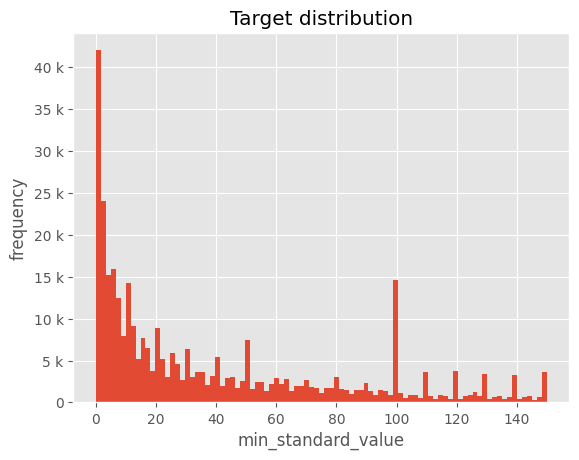

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


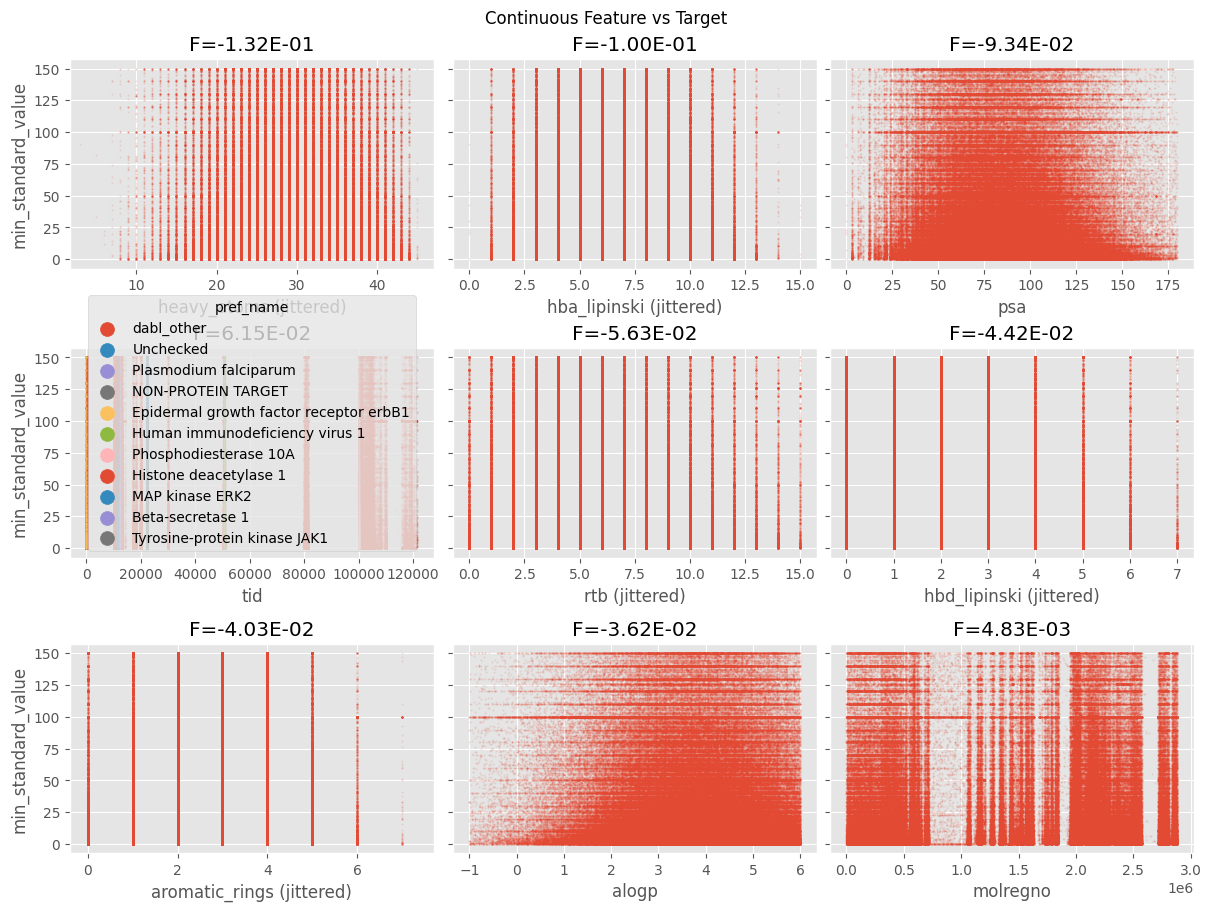

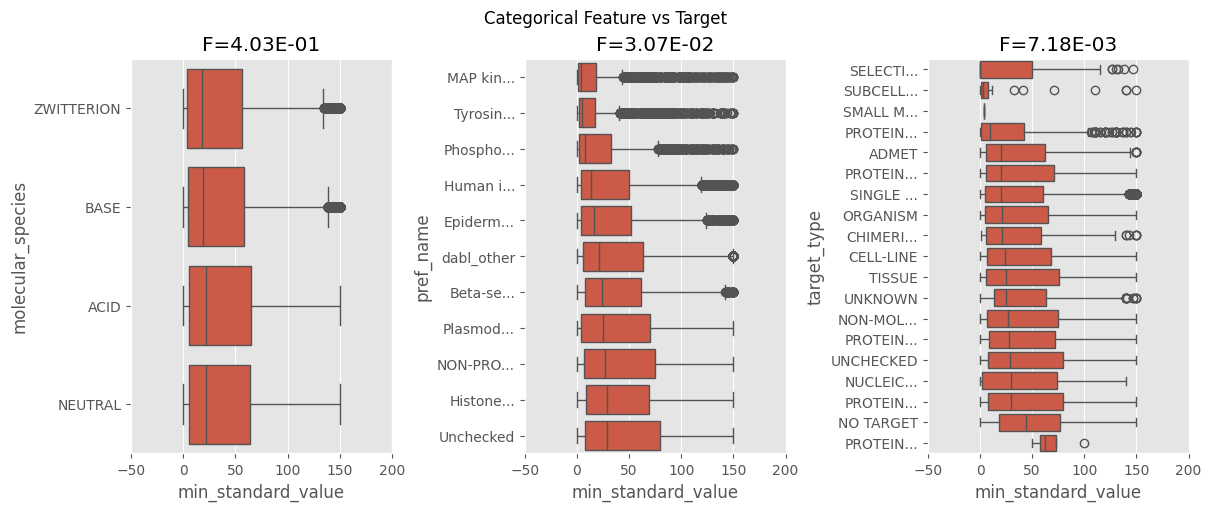

In [35]:
print("\nGenerating DABL Report...")
dabl.plot(eda_df, target_col="min_standard_value")
plt.show()

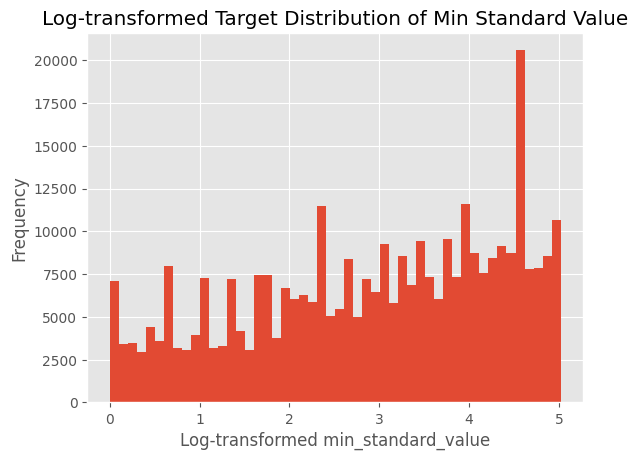

In [8]:
# Convert the 'min_standard_value' column to float
eda_df['min_standard_value'] = eda_df['min_standard_value'].astype(float)

# Apply the log transform
log_target = np.log1p(eda_df['min_standard_value'])

# Plot the log-transformed distribution
plt.hist(log_target, bins=50)
plt.title("Log-transformed Target Distribution of Min Standard Value")
plt.xlabel("Log-transformed min_standard_value")
plt.ylabel("Frequency")
plt.show()


# 




